In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv('fifa_world_cup_2026_player_performance.csv')

In [3]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [10]:
len(df.columns)

75

In [16]:
df['player_name'].dtypes

dtype('O')

In [6]:
df.shape

(54600, 75)

FIRST PERFORMING A DATA ANALYSIS

In [11]:
df.shape

(54600, 75)

In [12]:
df.groupby('player_id').count()

,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
player_id,,,,,,,,,,,,,,,,,,,,,
P00001,34,34,34,34,34,34,34,34,34,34,...,34,34,34,34,34,34,34,34,34,34
P00002,34,34,34,34,34,34,34,34,34,34,...,34,34,34,34,34,34,34,34,34,34
P00003,34,34,34,34,34,34,34,34,34,34,...,34,34,34,34,34,34,34,34,34,34
P00004,34,34,34,34,34,34,34,34,34,34,...,34,34,34,34,34,34,34,34,34,34
P00005,34,34,34,34,34,34,34,34,34,34,...,34,34,34,34,34,34,34,34,34,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P01244,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35
P01245,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35
P01246,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35


In [13]:
df.duplicated().any()

np.False_

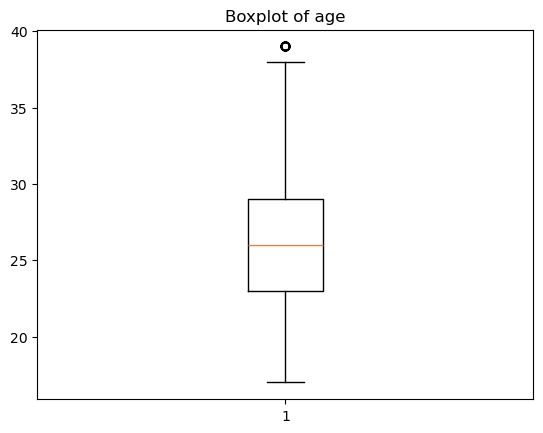

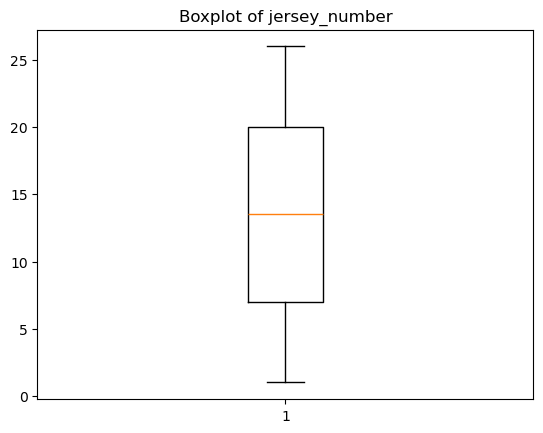

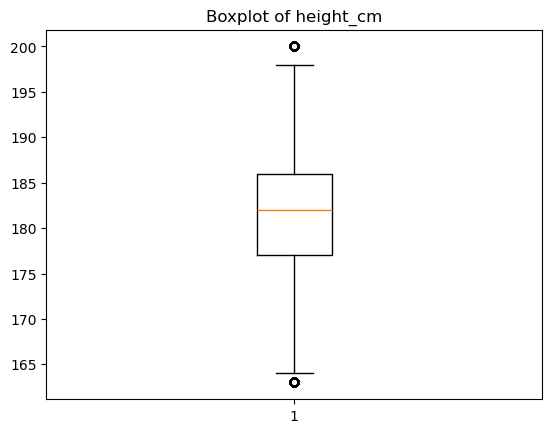

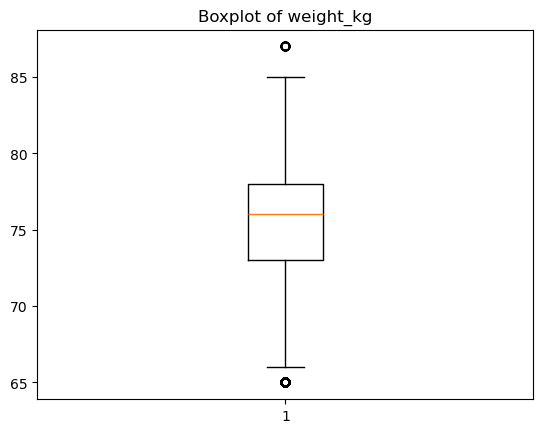

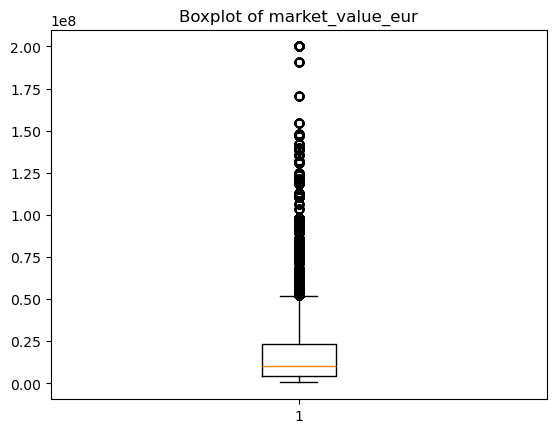

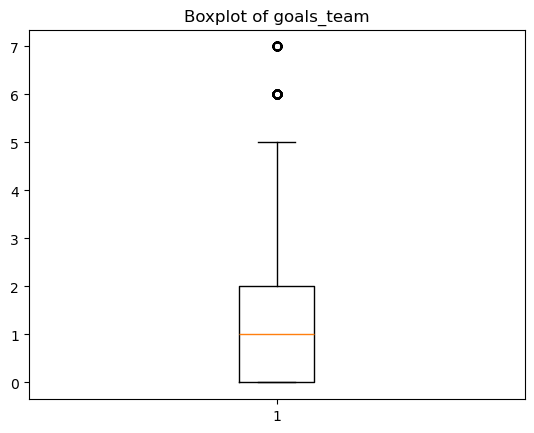

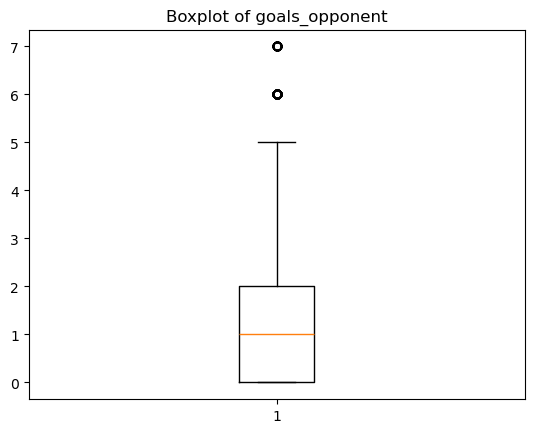

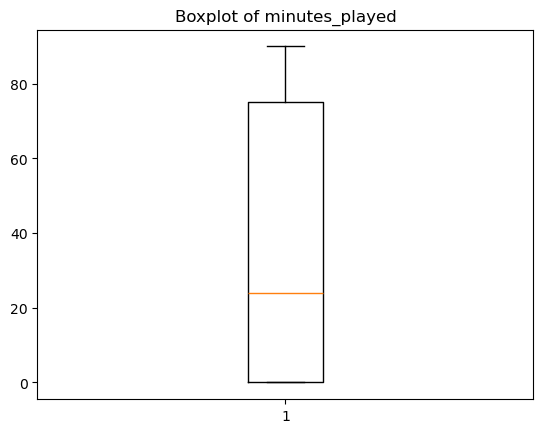

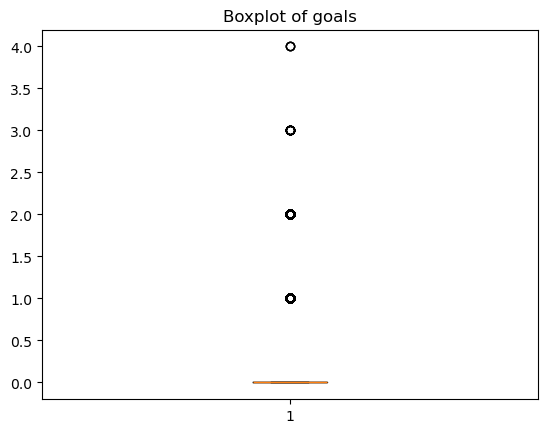

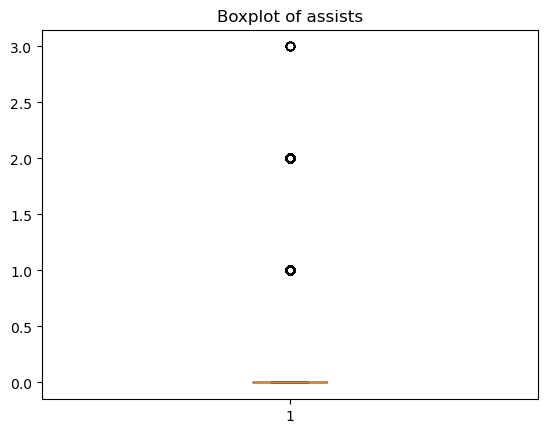

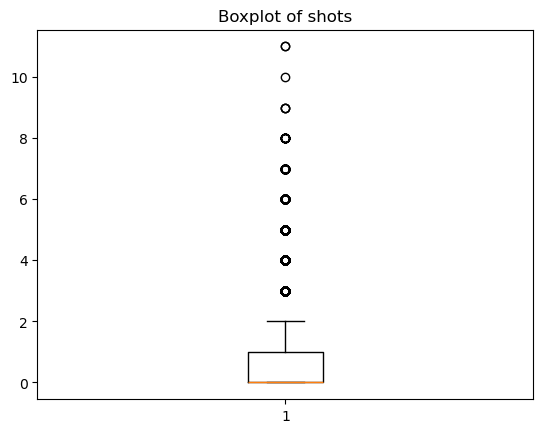

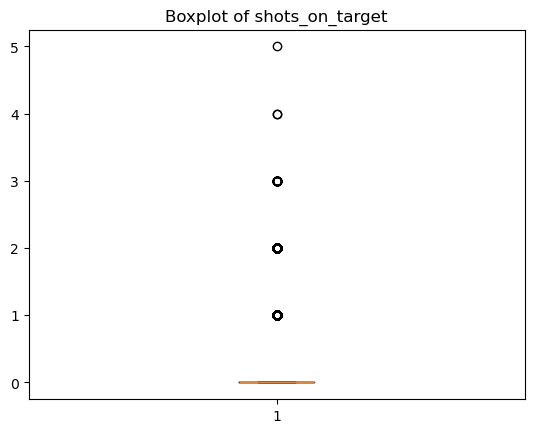

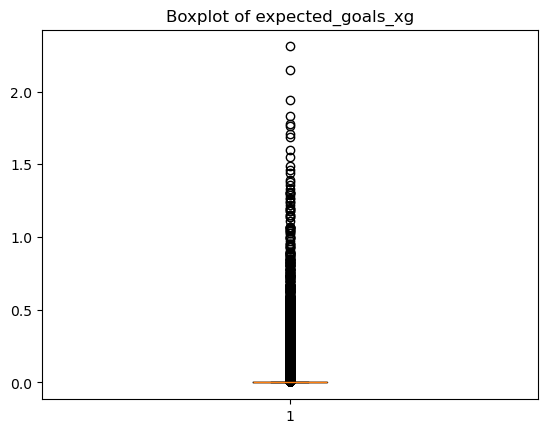

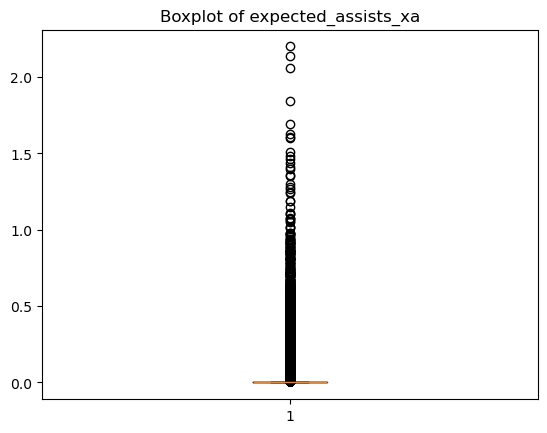

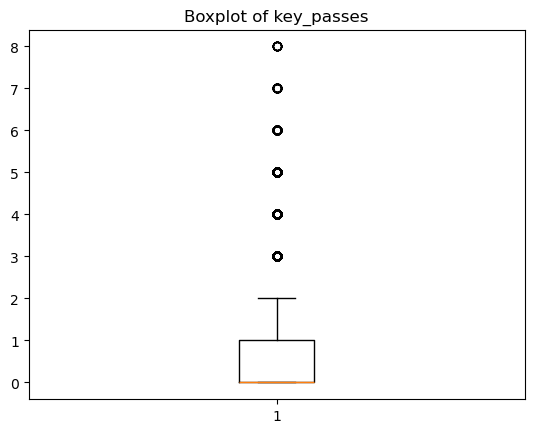

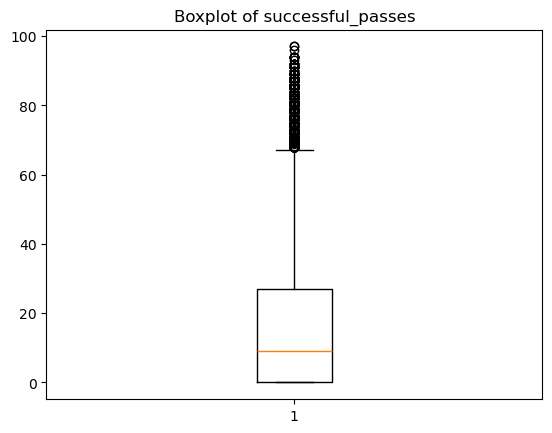

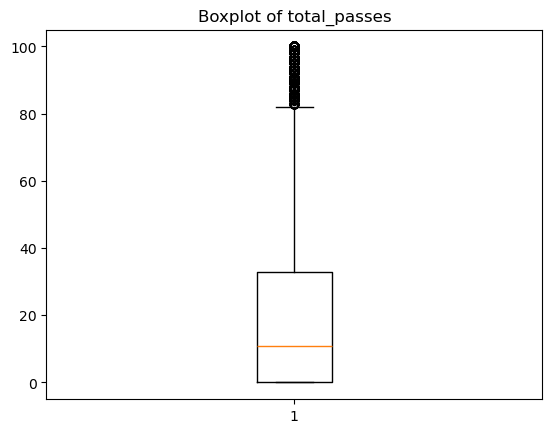

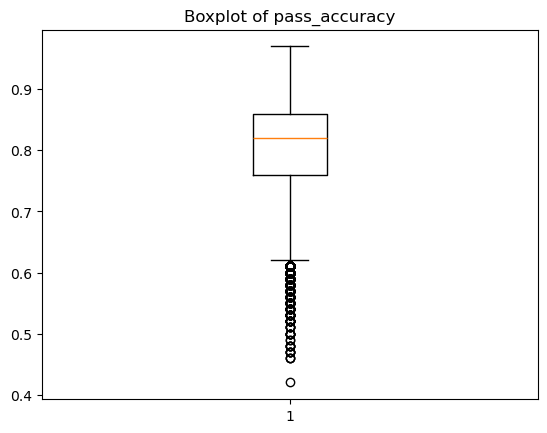

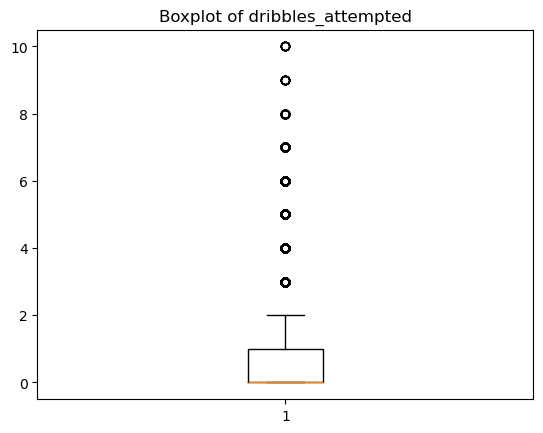

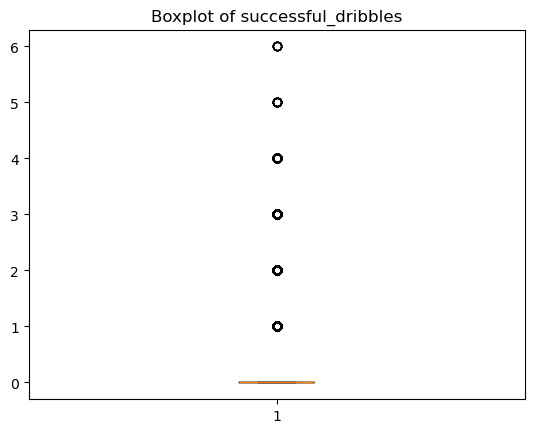

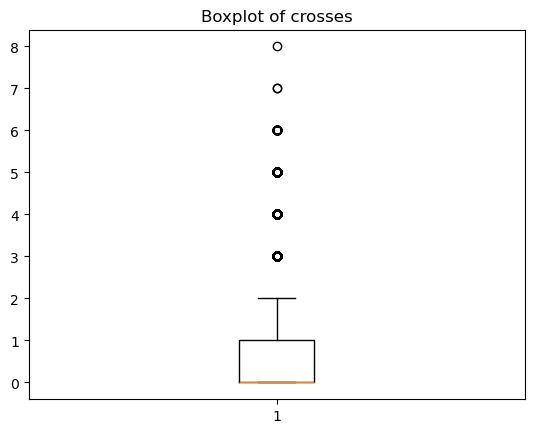

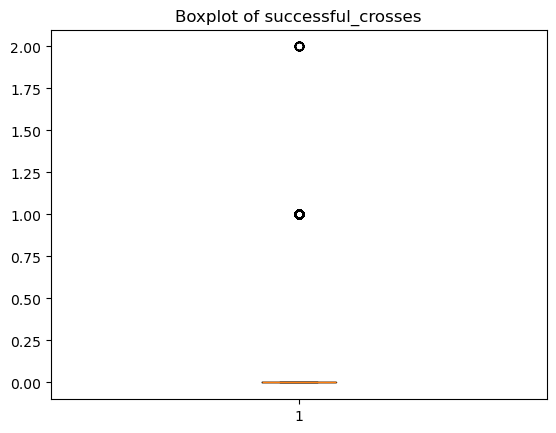

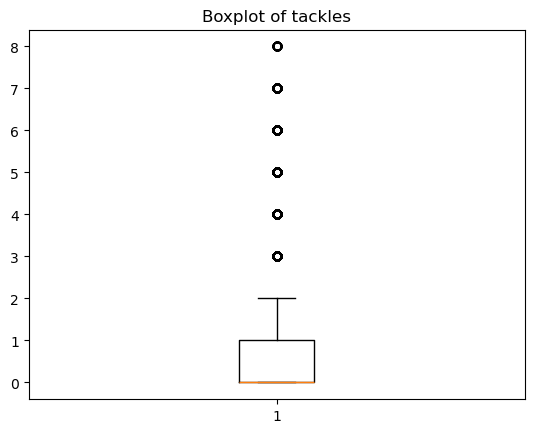

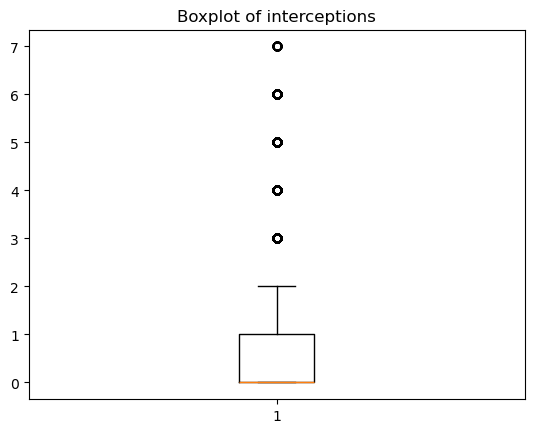

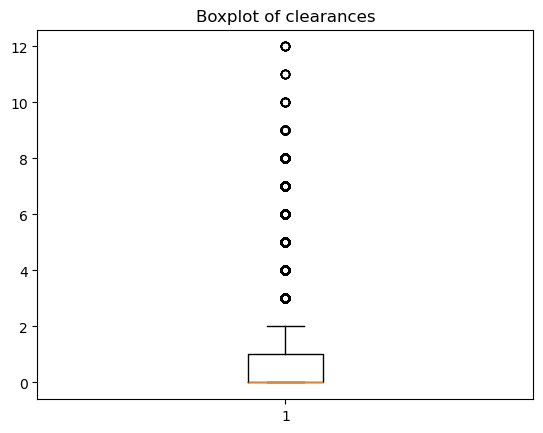

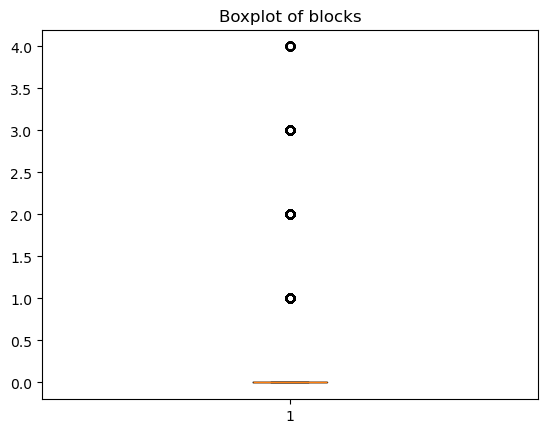

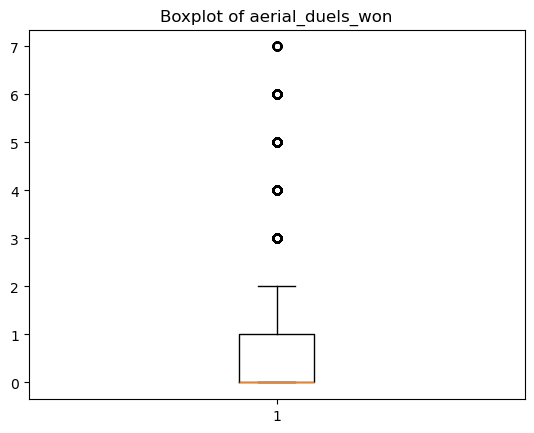

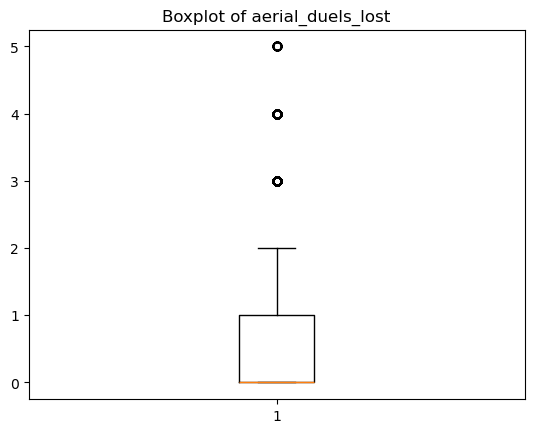

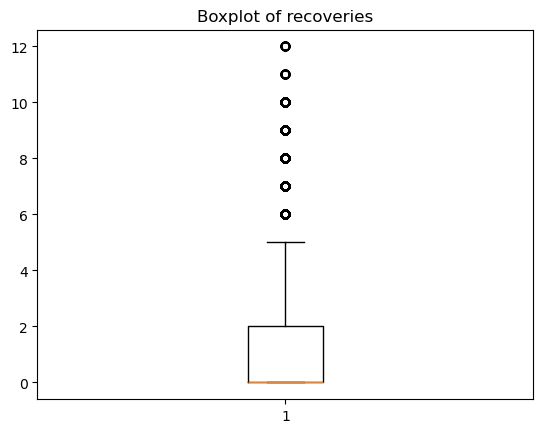

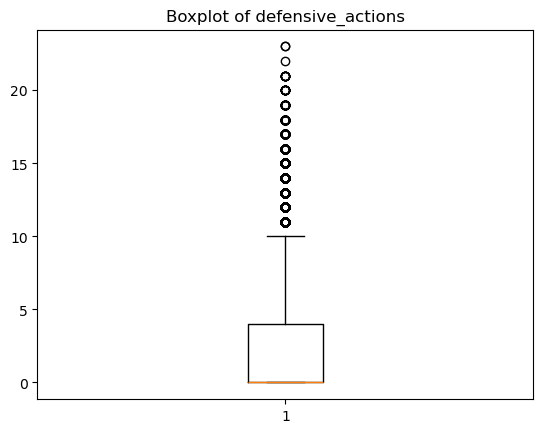

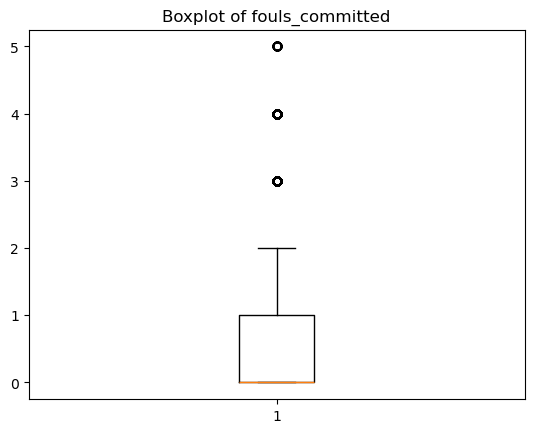

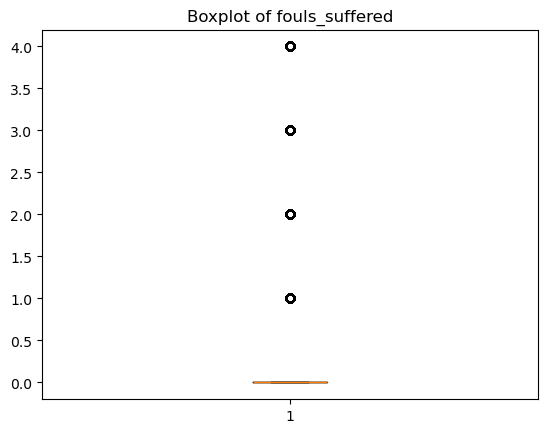

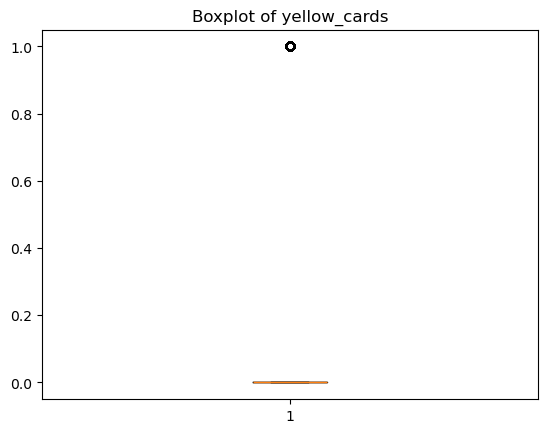

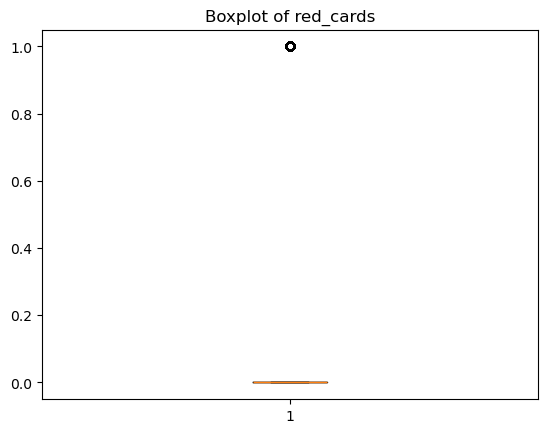

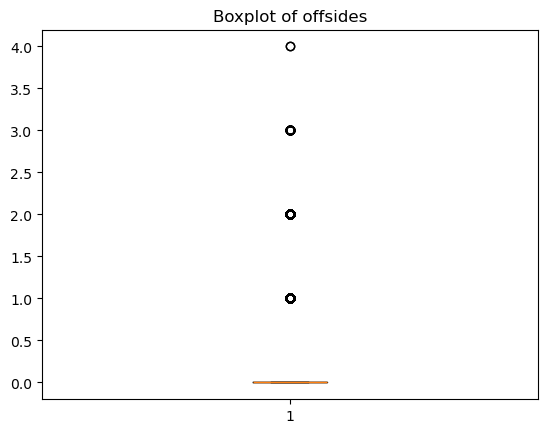

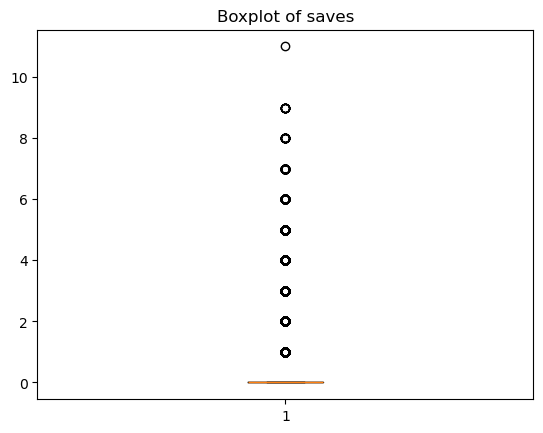

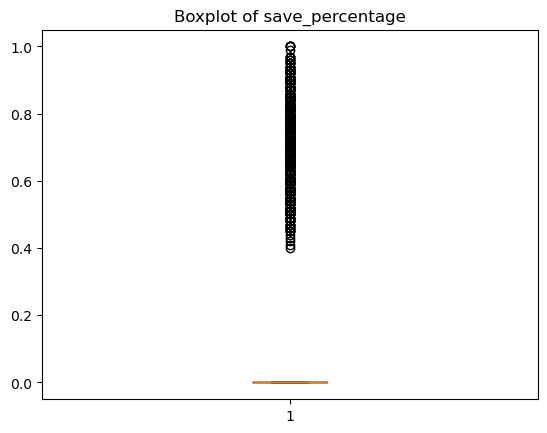

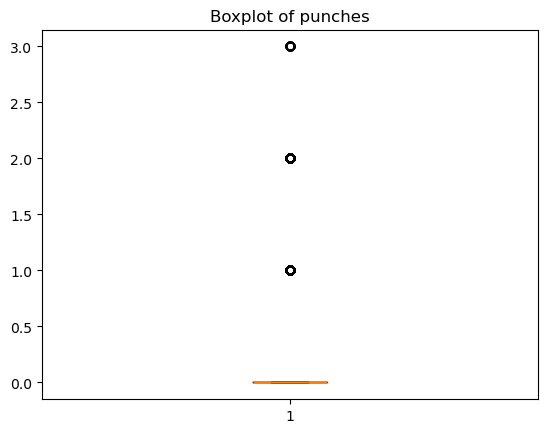

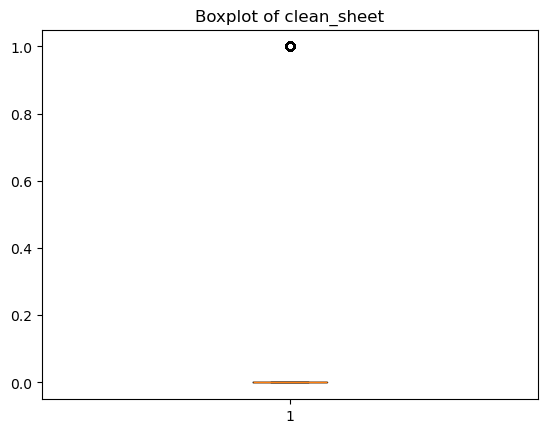

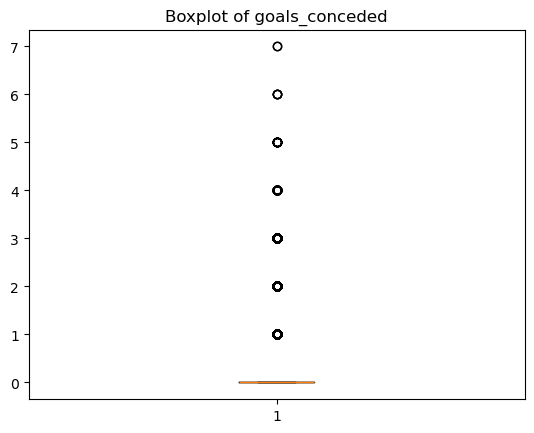

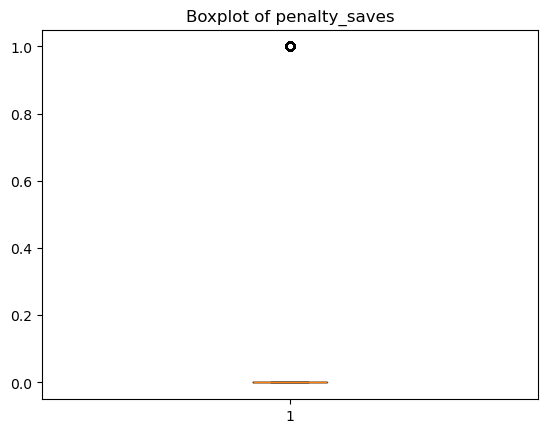

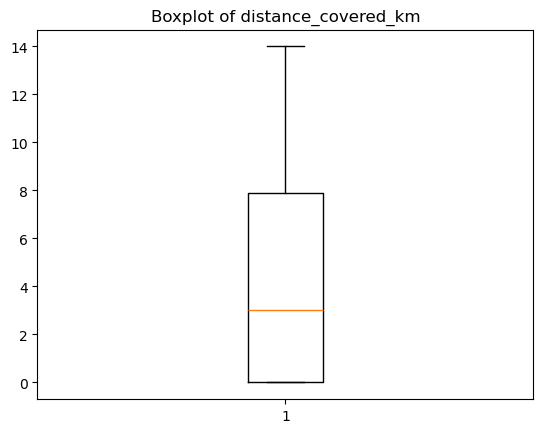

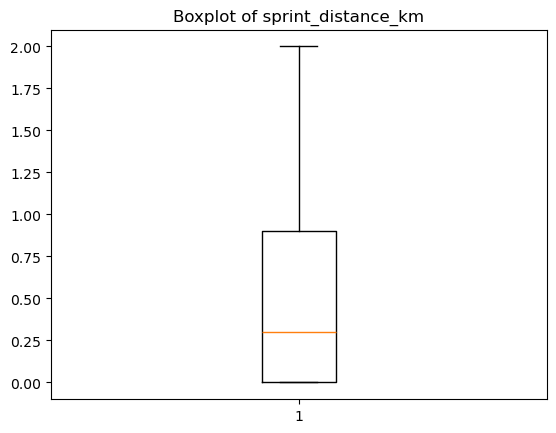

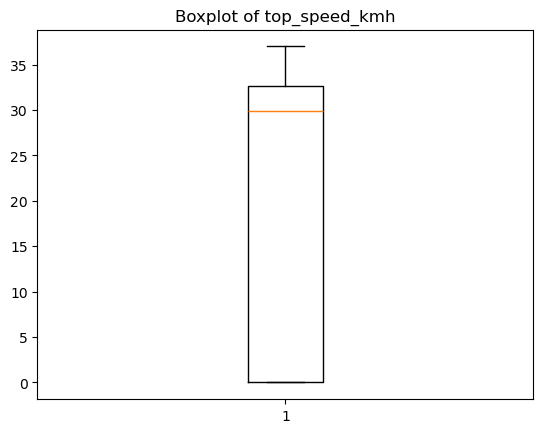

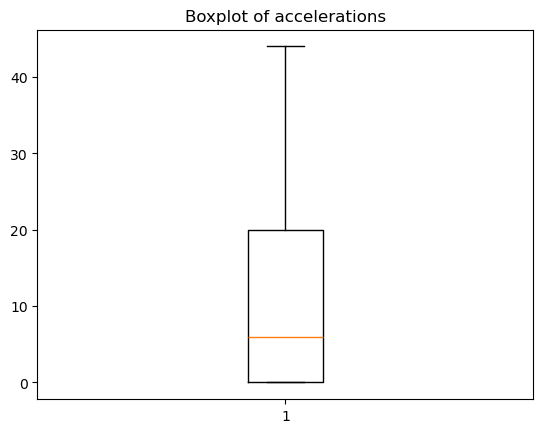

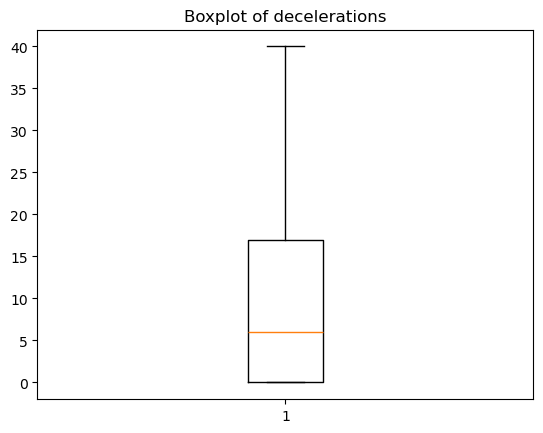

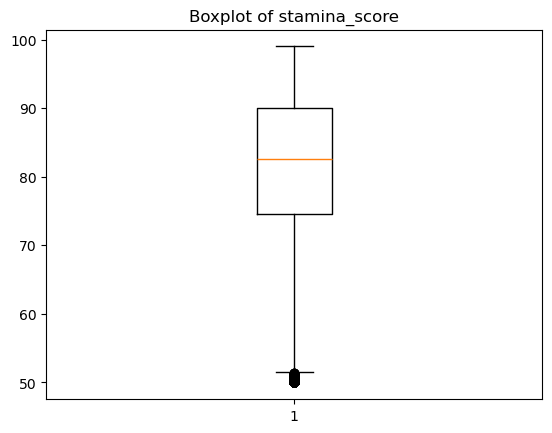

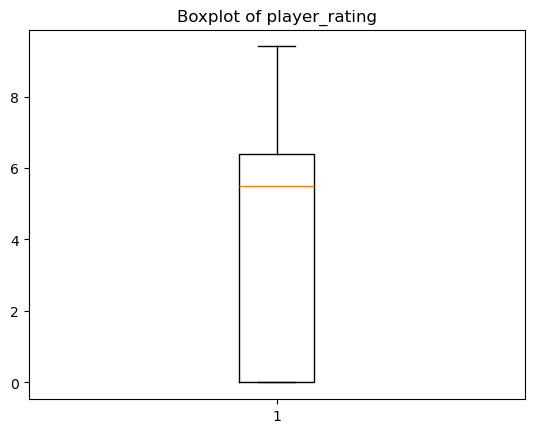

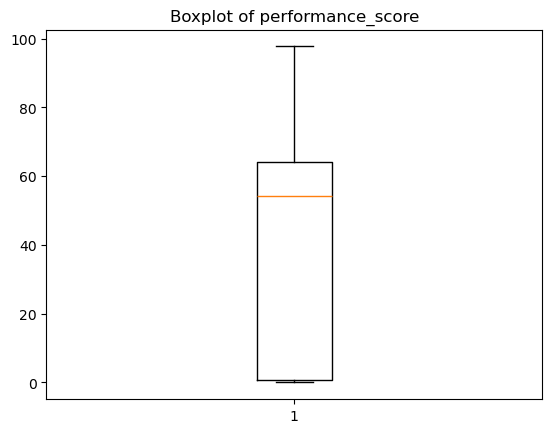

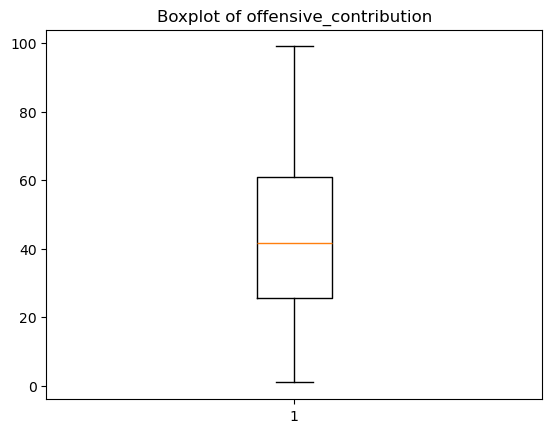

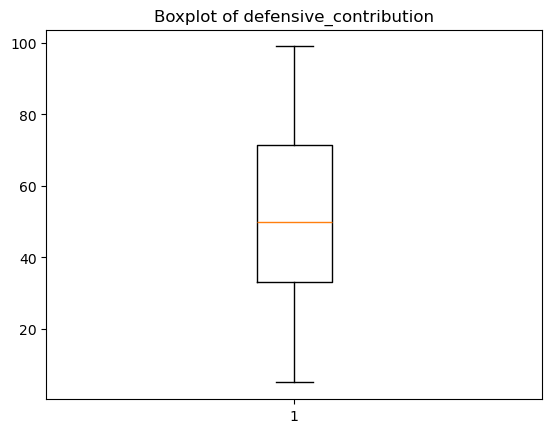

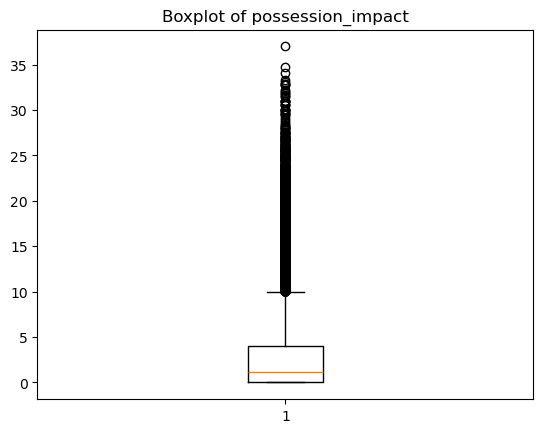

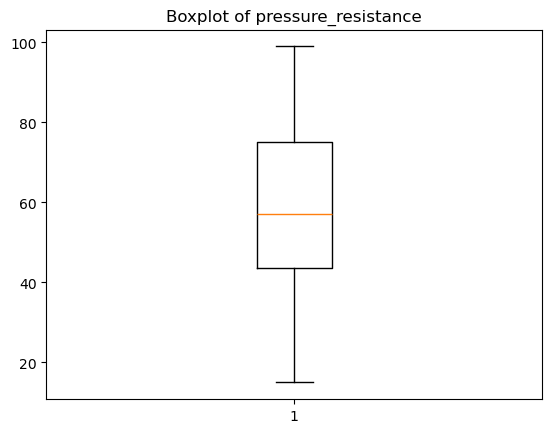

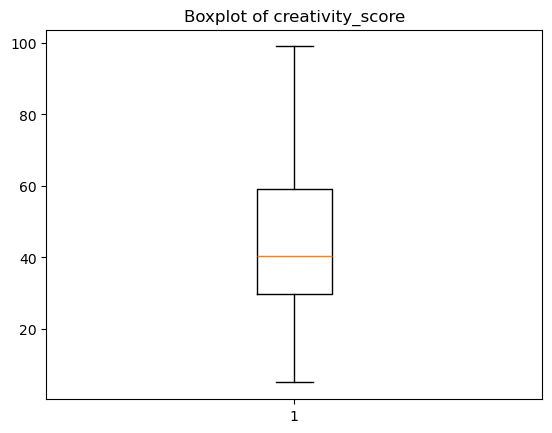

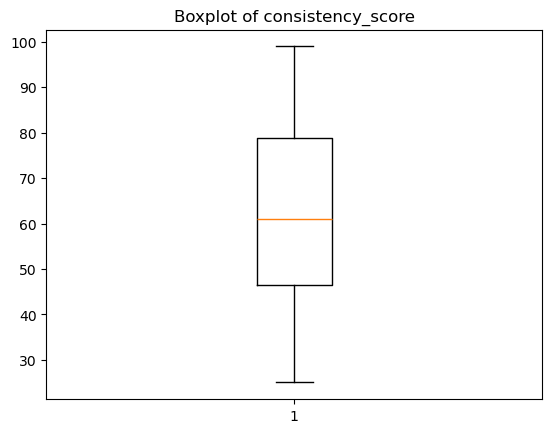

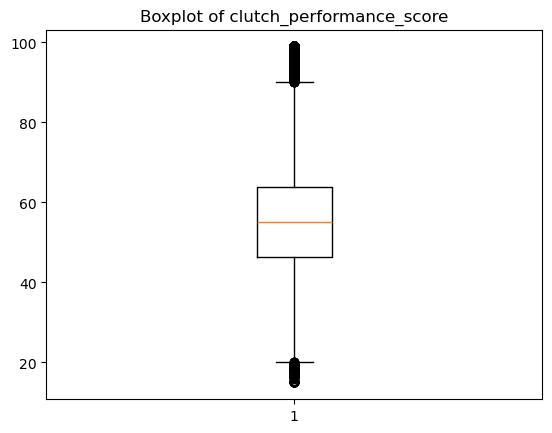

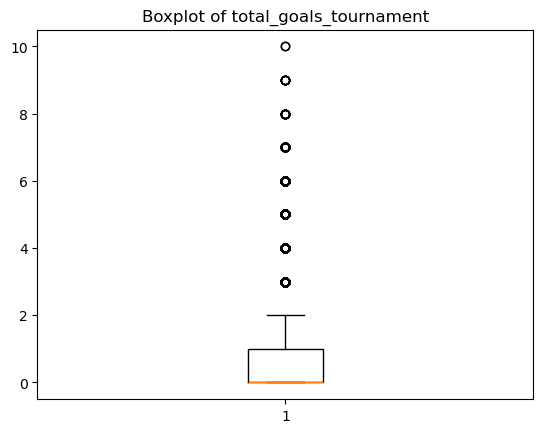

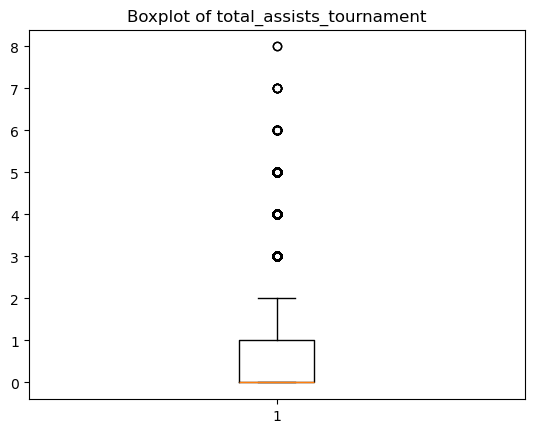

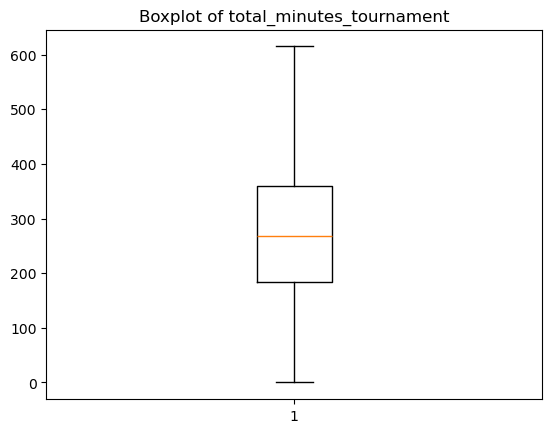

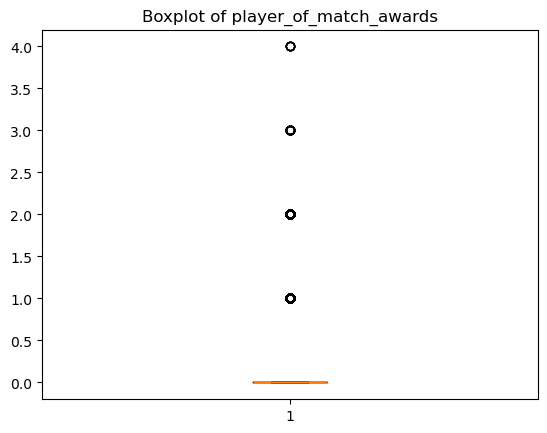

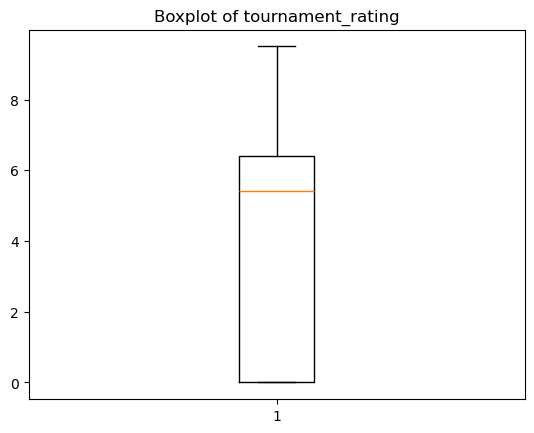

In [18]:
for i in df.columns:
    if (df[i].dtypes!='O'):
        plt.boxplot(df[i])
        plt.title(f"Boxplot of {i}") 
        plt.show()

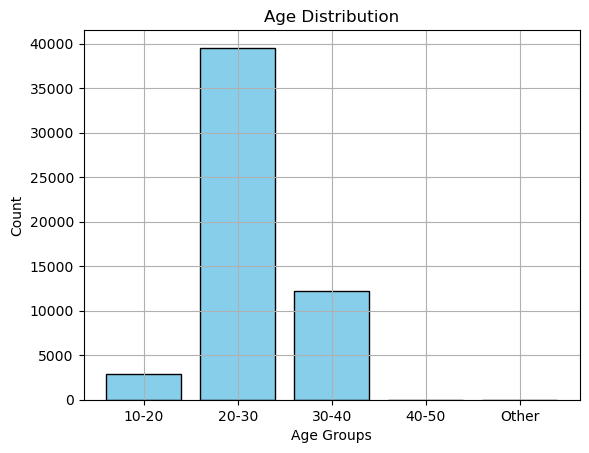

In [24]:
#checking the age collumn is corect or not 
'''
10-20 0
20-30 1
30-40 2
40-50 3
other 5
'''
lst=[0]*5
for i in df['age']:
    if 10<=i and i<20:
        lst[0]+=1
    elif 20<=i and i<30:
        lst[1]+=1
    elif 30<=i and i<40:
        lst[2]+=1 
    elif 40<=i and i<50:
        lst[3]+=1 
    else:
        lst[4]+=1
# The labels corresponding to your age bins
labels = ['10-20', '20-30', '30-40', '40-50', 'Other']

# Plotting the bar chart
plt.bar(labels, lst, color='skyblue', edgecolor='black')

# Adding titles and labels
plt.title('Age Distribution')
plt.xlabel('Age Groups')
plt.ylabel('Count')

# Display the graph
plt.grid()
plt.show()

In [22]:
df['age'].describe()

count    54600.000000
mean        26.296484
std          4.067519
min         17.000000
25%         23.000000
50%         26.000000
75%         29.000000
max         39.000000
Name: age, dtype: float64

In [10]:
#removing features directly from domain knowledge 
df.drop(['player_id', 'player_name','nationality','jersey_number'],axis=1,inplace=True)

In [14]:
df.head()

,age,team,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,26,Spain,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,19,Spain,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,18,Spain,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,20,Spain,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,23,Spain,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [17]:
#calculating missing values
df.isna().sum()

age                         0
team                        0
position                    0
height_cm                   0
weight_kg                   0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 71, dtype: int64